In [4]:
import h5py
from tqdm import tqdm
from score_models import NCSNppLog
from astropy.visualization import ImageNormalize, LogStretch
from scope.score_samplers import EulerMaruyama
from scope.definitions import DEVICE
import torch
import os, json, re
from glob import glob
import numpy as np
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Non-linear SDE prior sampling

In [5]:
# checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpplog_skirt_i_64_230517233328"
checkpoint_dir = "/home/aadam/scratch/DeblendingGalaxies/models/ncsnpplog_skirt_i_64_230519075909"


with open(os.path.join(checkpoint_dir, "model_hparams.json"), "r") as f:
    hyperparameters = json.load(f)
model = NCSNppLog(**hyperparameters).to(DEVICE)
paths = glob(os.path.join(checkpoint_dir, "checkpoint*.pt"))
checkpoints = [int(re.findall('[0-9]+', os.path.split(path)[-1])[-1]) for path in paths]
model.eval()
for p in model.parameters(): p.requires_grad = False  # being extra careful for some reasons
model.load_state_dict(torch.load(paths[np.argmax(checkpoints)], map_location=DEVICE))

<All keys matched successfully>

In [106]:
sum([np.prod(p.shape) for p in model.parameters()]) / 1e6

45.557828

In [156]:
sigma_min = hyperparameters["sigma_min"]
sigma_max = hyperparameters["sigma_max"]
beta0 = 1e5 # use a bigger value to avoid numerical instabilities when solving  #model.beta0
beta1 = model.beta1

def sigma(t):
    return sigma_min * (sigma_max / sigma_min)**t

def g(t): # VESDE diffusion coefficient
    return sigma(t).view(-1, 1, 1, 1) * np.sqrt(2 * (np.log(sigma_max) - np.log(sigma_min)))

In [157]:
def log_reversed_sde(y, t, dt, score_fn):
    B, *D = y.shape
    broadcast = [-1, *[1]*len(D)]
    score = score_fn(y - torch.log(beta0 + beta1*t.view(*broadcast)), t)
    new_y = y \
        + beta1 * torch.exp(-y) * dt \
        - g(t)**2 * torch.exp(-2*y) * score * dt \
        + 2 * g(t)**2 * torch.exp(-2* y) * dt \
        + torch.exp(-y) * g(t) * torch.randn_like(y) * np.sqrt(-dt) \
        - 0.5 * g(t)**2 * torch.exp(-2*y) * dt
    return new_y, score

In [158]:
def linear_reversed_sde(x, t, dt, score_fn):
    B, *D = y.shape
    broadcast = [-1, *[1]*len(D)]
    return x \
        + beta1 * torch.ones_like(x) * dt \
        - g(t)**2 / x * score_fn(torch.log(x) - torch.log(beta0 + beta1*t.view(*broadcast)), t) * dt \
        + g(t)**2 / x * dt \
        + g(t) * torch.randn_like(x) * np.sqrt(-dt)

In [159]:
B = 8
N = 2000

# Reverse SDE
y = torch.log(torch.randn([B, 1, 64, 64]) * sigma_max + beta1 + beta0).to(DEVICE)
chain_nonlinear = []
score_list = []
t = torch.ones(B).to(DEVICE)
dt = -1/N
with torch.no_grad():
    for n in tqdm(range(N)):
        y, score = log_reversed_sde(y, t, dt, model.score)
        t += dt
        if (n+1) % 100 == 0:
            chain_nonlinear.append(y.cpu().numpy())
            score_list.append(score.cpu().numpy())

100%|██████████| 2000/2000 [02:09<00:00, 15.41it/s]


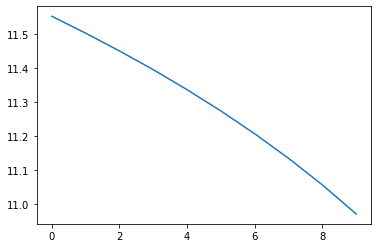

In [160]:
plt.plot([t.mean() for t in chain_nonlinear])

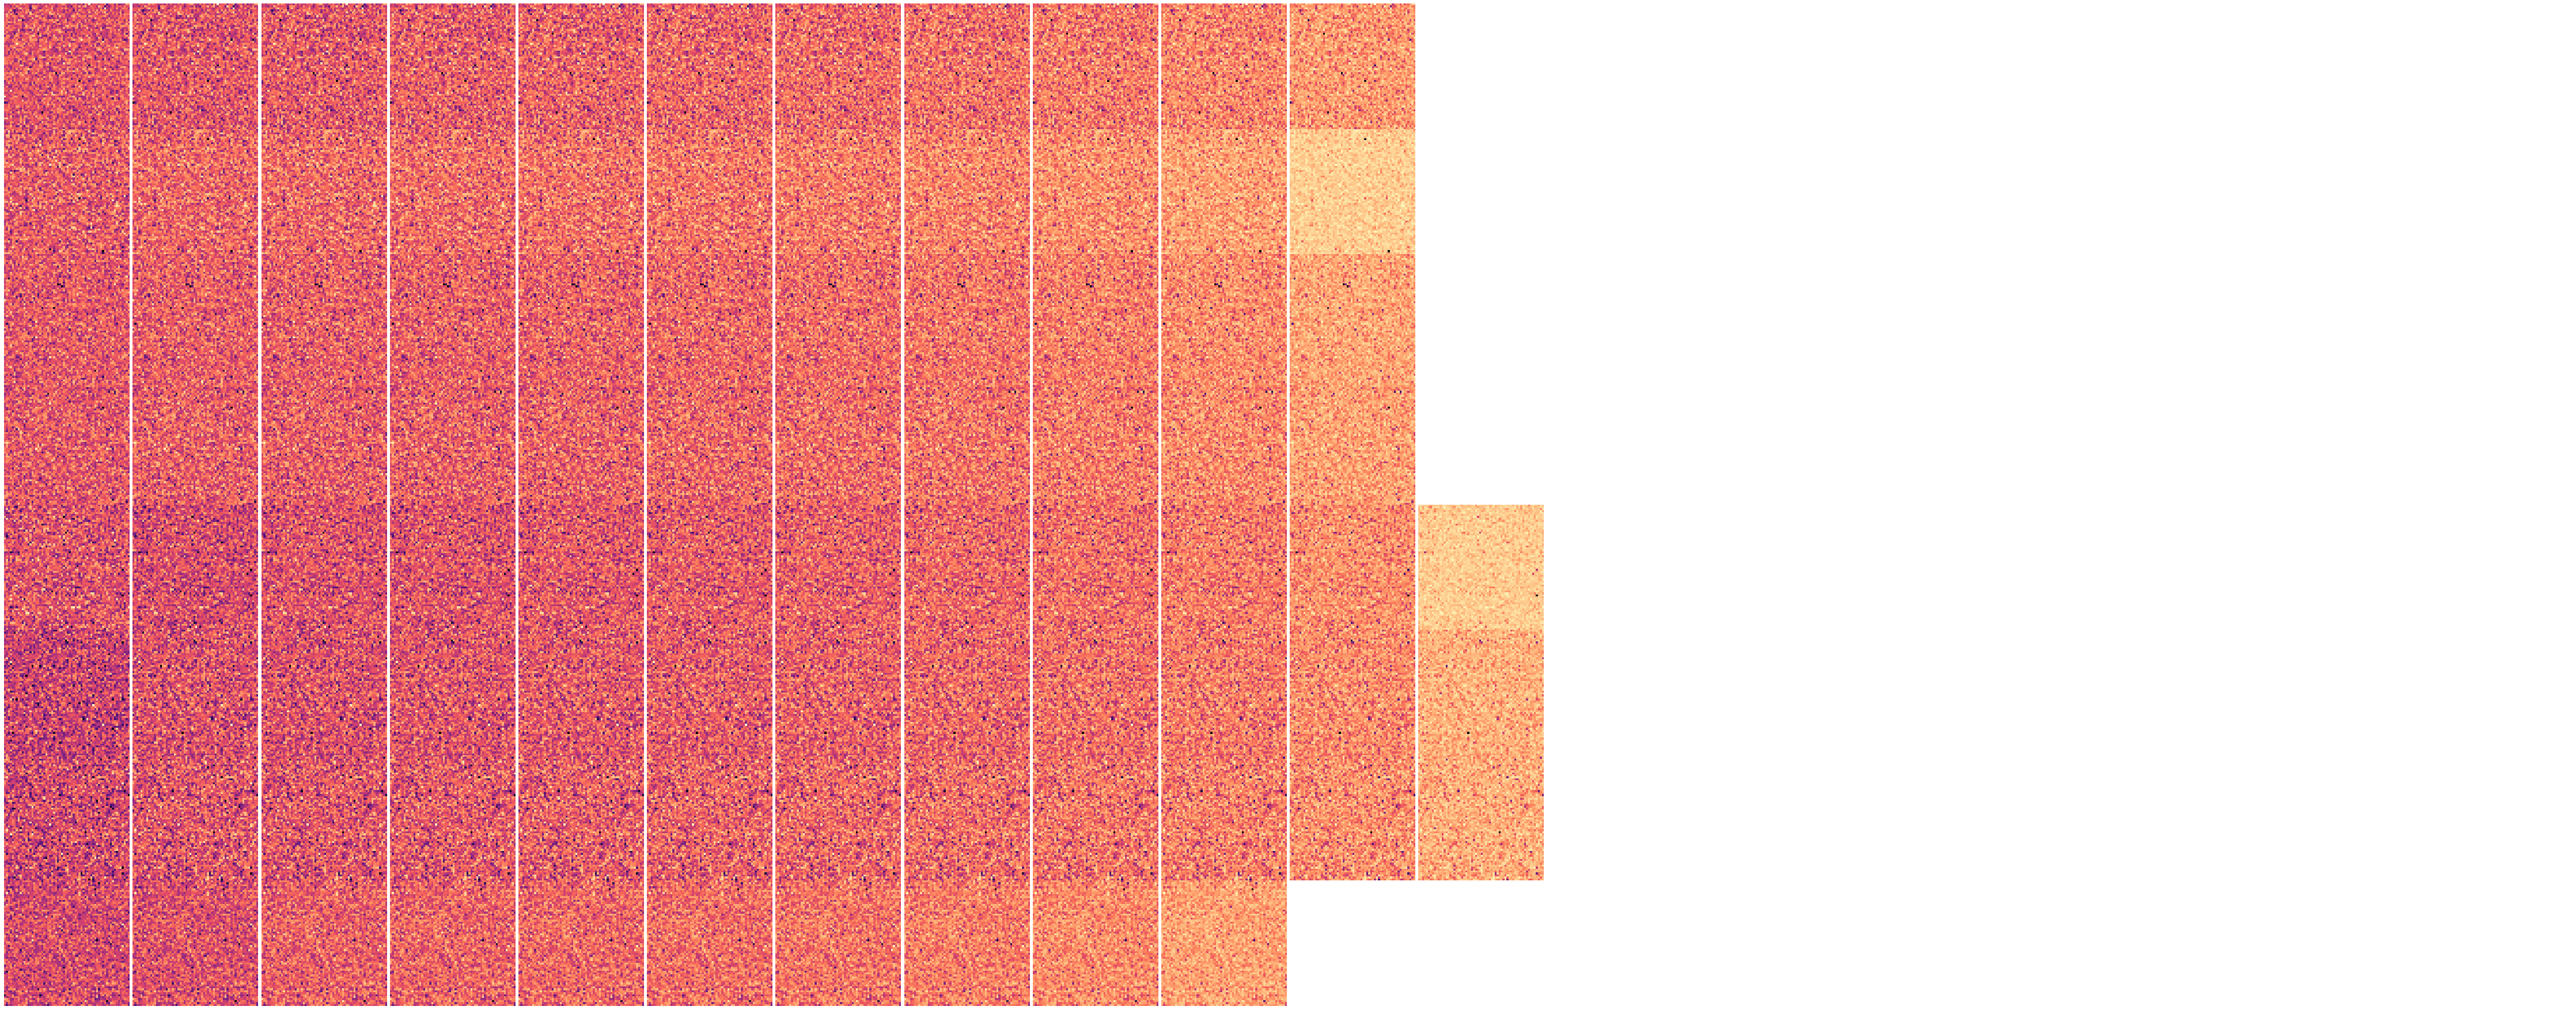

In [161]:
fig , axs = plt.subplots(8, 20, figsize=(20*4, 4*8))

for i in range(8):
    for j in range(20):
        axs[i, j].imshow(chain_nonlinear[j][i, 0], cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

In [11]:
B = 8
N = 2000

# Reverse SDE
x = (torch.randn([B, 1, 64, 64]) * sigma_max + beta1 + beta0).to(DEVICE)
chain_linear = []
t = torch.ones(B).to(DEVICE)
dt = -1/N
with torch.no_grad():
    for n in tqdm(range(N)):
        x = linear_reversed_sde(x, t, dt, model.score)
        t += dt
        if (n+1) % 100 == 0:
            chain_linear.append(x.cpu().numpy())

 17%|█▋        | 337/2000 [00:21<01:47, 15.48it/s]

KeyboardInterrupt



In [ ]:
fig , axs = plt.subplots(8, 20, figsize=(20*4, 4*8))

for i in range(8):
    for j in range(20):
        axs[i, j].imshow(chain_linear[j][i, 0], cmap="magma")
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)